Submitted by Marielle Alexa A. Salvador

In [ ]:
!pip install lightkurve
import lightkurve as lk
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.6/199.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 72.4 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=5bc396edfe70eaafefdfdfac5e5aa547819c2ce104cde8d8a59fedafc116e8b3
  Stored in directory: /root/.cache/pip/wheels/71/ae/f7/5b7e1e16a133d094431428169e9a8d9f750afe5459f0333c9b
  Created wheel for memoization: 

/usr/local/lib/python3.11/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


#Accessing Data Product

In [ ]:
TIC = 'TIC 231663901'
sector_data = lk.search_lightcurve(TIC)
sector_data

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,231663901,0.0
1,TESS Sector 27,2020,SPOC,20,231663901,0.0
2,TESS Sector 27,2020,SPOC,120,231663901,0.0
3,TESS Sector 67,2023,SPOC,120,231663901,0.0
4,TESS Sector 94,2025,SPOC,120,231663901,0.0
5,TESS Sector 01,2018,TESS-SPOC,1800,231663901,0.0
6,TESS Sector 27,2020,TESS-SPOC,600,231663901,0.0
7,TESS Sector 67,2023,TESS-SPOC,200,231663901,0.0
8,TESS Sector 01,2018,QLP,1800,231663901,0.0


In [ ]:
lc = lk.search_lightcurve(TIC)[1].download()
lc.info()

<TessLightCurve length=100704>
      name       dtype      unit      format      class      n_bad 
--------------- ------- ------------ -------- -------------- ------
           time  object                                 Time      0
           flux float32 electron / s {:14.7e} MaskedQuantity   1998
       flux_err float32 electron / s {:14.7e} MaskedQuantity   1998
       timecorr float32            d {:14.7e}       Quantity      0
      cadenceno   int32                {:10d}         Column      0
   centroid_col float64          pix {:10.5f} MaskedQuantity      0
   centroid_row float64          pix {:10.5f} MaskedQuantity      0
       sap_flux float32 electron / s {:14.7e} MaskedQuantity      0
   sap_flux_err float32 electron / s {:14.7e} MaskedQuantity      0
        sap_bkg float32 electron / s {:14.7e} MaskedQuantity      0
    sap_bkg_err float32 electron / s {:14.7e} MaskedQuantity      0
    pdcsap_flux float32 electron / s {:14.7e} MaskedQuantity   1998
pdcsap_flux_err f

#Download the data and plot the light curve

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

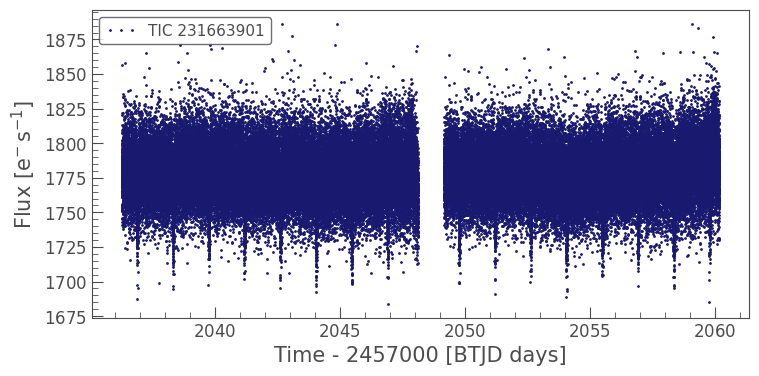

In [ ]:
sector_data = lk.search_lightcurve(TIC)
lc = sector_data[1].download()
lc.plot(linewidth= 0, marker = '.', color = 'midnightblue', alpha = 1 )

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

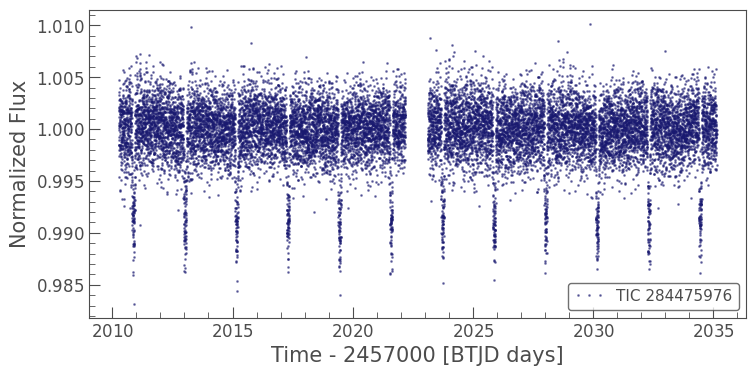

In [ ]:
lc_norm = lc.normalize()
lc_norm.plot(linewidth= 0, marker = '.', color = 'midnightblue', alpha = 0.5 )

#Manipulating the Light Curve

In [ ]:
#Phase Folding
period = lc.to_periodogram(method='bls').period_at_max_power
print ('period =', period)

transit_duration = lc.to_periodogram(method='bls').duration_at_max_power
print ('transit_duration =', transit_duration)

epoch = lc.to_periodogram(method='bls').transit_time_at_max_power
print ('epoch =', epoch)

period = 1.4299756558595116 d
transit_duration = 0.05 d
epoch = 2036.9075550153882


Text(0.5, 1.0, 'Time Averaged and Phase-folded Light Curve (Transit)')

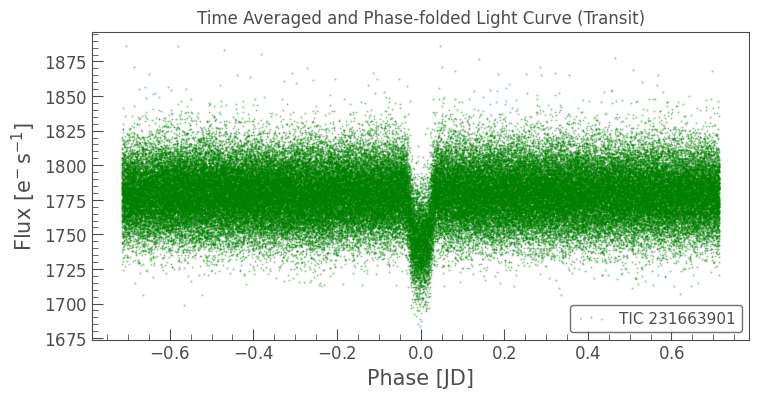

In [ ]:
lc.fold(period=period, epoch_time=epoch).scatter(color = 'g', marker = '.', alpha = 0.3, linewidth = 0.5).set_title('Time Averaged and Phase-folded Light Curve (Transit)')

Text(0.5, 1.0, 'Time Averaged and Phase-folded Light Curve (Period)')

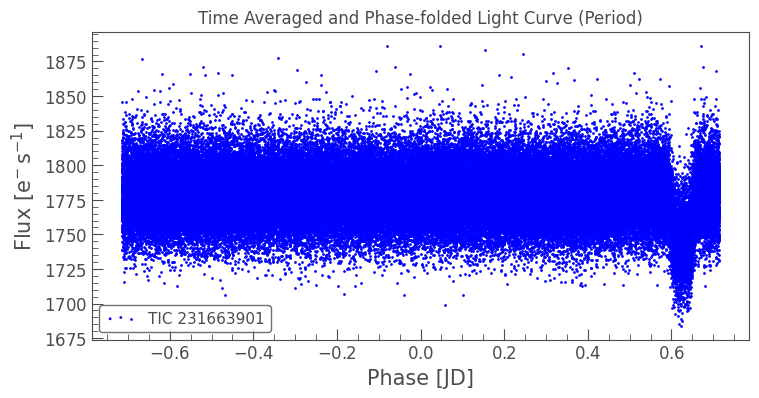

In [ ]:
#another way to phase fold
lc.fold(period).scatter(linewidth = 0,
                        marker = 'o', color = 'blue',
                        alpha = 1).set_title("Time Averaged and Phase-folded Light Curve (Period)")

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

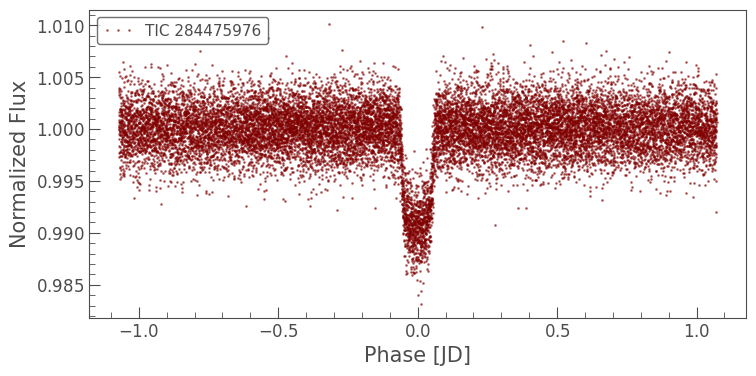

In [ ]:
t0 = 2825.459527
period = 2.14363
lc_phased = lc_norm.fold(period = period, epoch_time = t0)
lc_phased.plot(linewidth =0, color = 'maroon', marker='.', alpha= 0.5 )

(-0.5, 0.5)

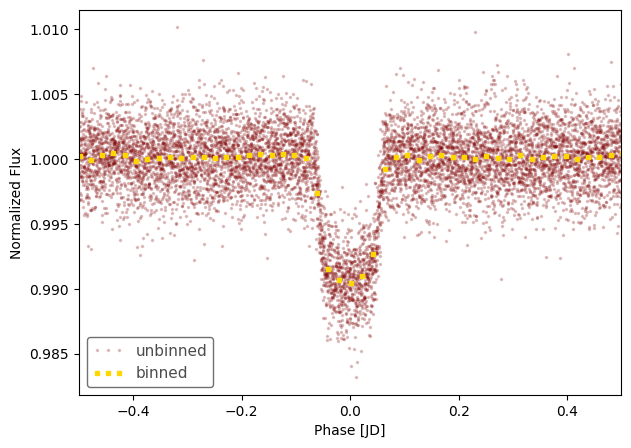

In [ ]:
#Binning
lc_phased_binned = lc_phased.bin (30/24/60)
fig, ax = plt.subplots (figsize = (7,5))
lc_phased.plot(ax = ax, marker = '.', linewidth = 0, color = 'maroon', alpha = 0.2, markersize = 3, label = "unbinned")
lc_phased_binned.plot(ax= ax, marker = 's', linewidth= 0, color = 'gold', alpha = 1, markersize = 3, label = "binned")
plt.xlim(-0.5,0.5)